In [1]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.1 MB/s eta 0:00:00


In [3]:
from faker import Faker

In [4]:
fake=Faker()

In [5]:

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
np.random.seed(42)

n = 250

names = [f"Student_{i}" for i in range(1, n+1)]
genders = np.random.choice(['Male', 'Female'], n)
departments = np.random.choice(['CSE', 'IT', 'ECE'], n)
years = np.random.choice(['1st', '2nd', '3rd'], n)

data = pd.DataFrame({
    'Student_ID': range(1, n+1),
    'Name': names,
    'Gender': genders,
    'Department': departments,
    'Year': years,
    'Maths': np.random.randint(40, 100, n),
    'Science': np.random.randint(40, 100, n),
    'English': np.random.randint(40, 100, n),
    'Attendance': np.random.randint(50, 101, n),
    'Internal_Marks': np.random.randint(0, 26, n)
})

In [9]:
data['Total'] = data[['Maths', 'Science', 'English']].sum(axis=1)
data['Average'] = data['Total'] / 3

# Grade Classification
def grade(avg):
    if avg >= 90:
        return 'A'
    elif avg >= 75:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'Fail'

data['Grade'] = data['Average'].apply(grade)

In [10]:
print("\nSummary Statistics:\n", data.describe())



Summary Statistics:
        Student_ID       Maths     Science     English  Attendance  \
count  250.000000  250.000000  250.000000  250.000000  250.000000   
mean   125.500000   69.608000   68.468000   70.200000   75.248000   
std     72.312977   17.921917   17.515139   16.749513   14.392745   
min      1.000000   40.000000   40.000000   40.000000   50.000000   
25%     63.250000   54.250000   53.000000   57.000000   63.250000   
50%    125.500000   69.000000   67.500000   70.500000   74.000000   
75%    187.750000   86.750000   84.000000   85.750000   87.000000   
max    250.000000   99.000000   99.000000   99.000000  100.000000   

       Internal_Marks       Total     Average  
count      250.000000  250.000000  250.000000  
mean        11.936000  208.276000   69.425333  
std          7.452925   31.612104   10.537368  
min          0.000000  129.000000   43.000000  
25%          6.000000  183.000000   61.000000  
50%         12.000000  209.000000   69.666667  
75%         17.00000

In [11]:
top_students = data.sort_values(by='Total', ascending=False).head(10)
low_students = data[data['Grade'] == 'Fail']

print("\nTop Students:\n", top_students[['Name', 'Total']])
print("\nLow Performing Students:\n", low_students[['Name', 'Total']])



Top Students:
             Name  Total
51    Student_52    288
189  Student_190    283
219  Student_220    277
19    Student_20    276
150  Student_151    275
162  Student_163    274
244  Student_245    272
111  Student_112    271
27    Student_28    270
110  Student_111    268

Low Performing Students:
             Name  Total
31    Student_32    148
90    Student_91    141
119  Student_120    146
156  Student_157    129
159  Student_160    140
172  Student_173    146
202  Student_203    147
232  Student_233    147
247  Student_248    143


In [12]:
print("\nDepartment-wise Average:\n", data.groupby('Department')['Average'].mean())
print("\nGender-wise Average:\n", data.groupby('Gender')['Average'].mean())
print("\nYear-wise Average:\n", data.groupby('Year')['Average'].mean())


Department-wise Average:
 Department
CSE    68.420635
ECE    70.012195
IT     69.857143
Name: Average, dtype: float64

Gender-wise Average:
 Gender
Female    69.755376
Male      69.100529
Name: Average, dtype: float64

Year-wise Average:
 Year
1st    69.580000
2nd    69.534188
3rd    69.092593
Name: Average, dtype: float64


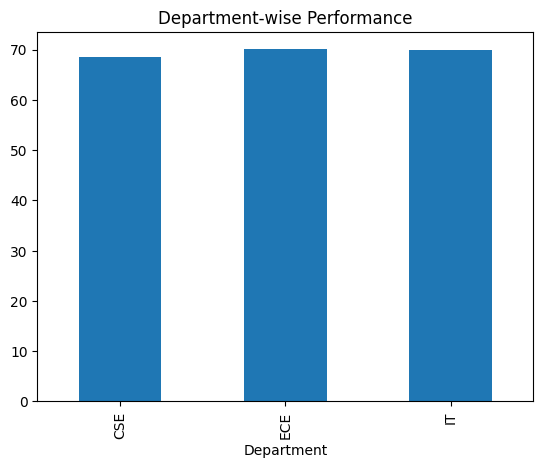

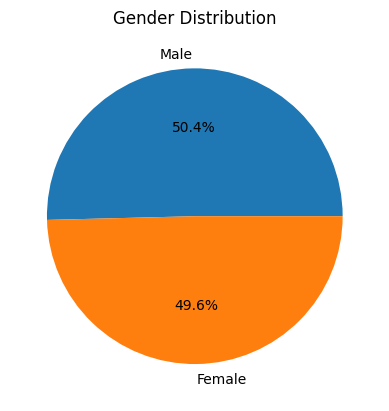

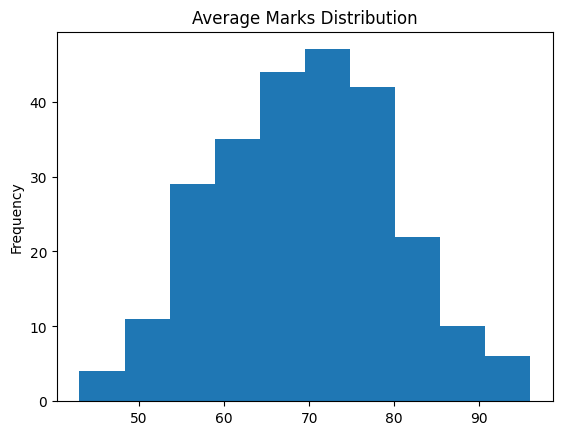

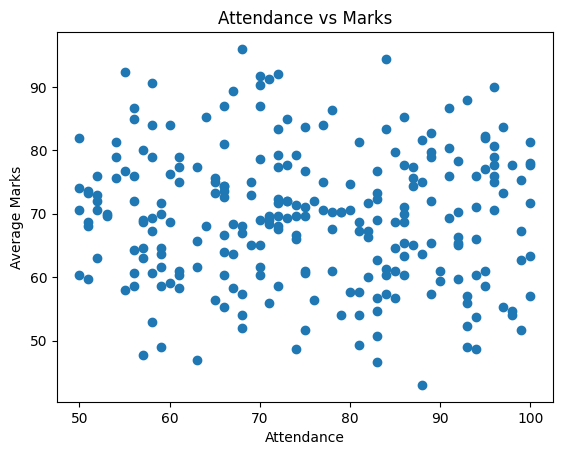

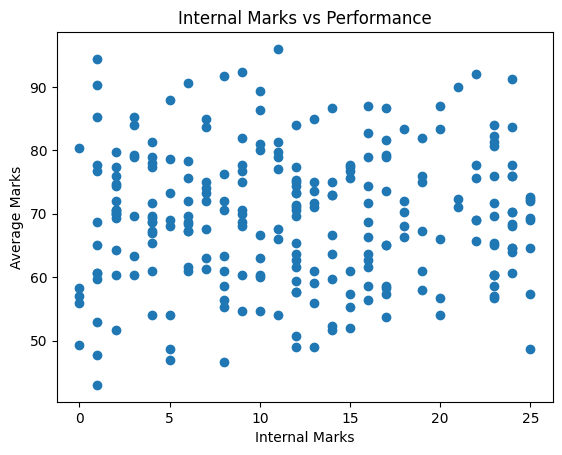

In [13]:
# Bar Chart - Department Performance
data.groupby('Department')['Average'].mean().plot(kind='bar', title='Department-wise Performance')
plt.show()

# Pie Chart - Gender Distribution
data['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Gender Distribution')
plt.ylabel('')
plt.show()

# Histogram - Marks Distribution
data['Average'].plot(kind='hist', bins=10, title='Average Marks Distribution')
plt.show()

# Scatter Plot - Attendance vs Marks
plt.scatter(data['Attendance'], data['Average'])
plt.xlabel('Attendance')
plt.ylabel('Average Marks')
plt.title('Attendance vs Marks')
plt.show()

# Internal Marks vs Performance
plt.scatter(data['Internal_Marks'], data['Average'])
plt.xlabel('Internal Marks')
plt.ylabel('Average Marks')
plt.title('Internal Marks vs Performance')
plt.show()


In [14]:
print("\nInsights:")
print("- Students with higher attendance tend to score better.")
print("- Internal marks show positive relation with final performance.")
print("- Department-wise performance varies slightly.")


Insights:
- Students with higher attendance tend to score better.
- Internal marks show positive relation with final performance.
- Department-wise performance varies slightly.
